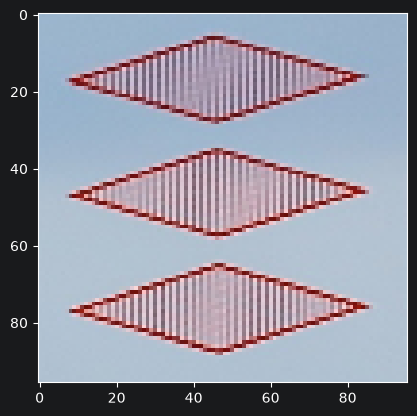

In [165]:
import cv2 as cv2
import numpy as np
import matplotlib.pyplot as plt

# Read image
img = cv2.imread("cards - annotated/card24_r_3_s_v.jpg")   # Change to your filename
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (96, 96))

plt.imshow(img)





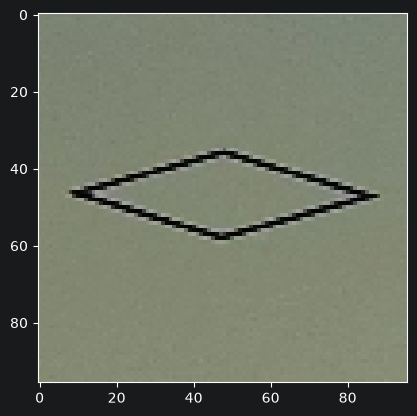

In [166]:
img = cv2.imread("cards - annotated/card229_b_1_l_v.jpg")   # Change to your filename
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
img = cv2.resize(img, (96, 96))

plt.imshow(img)

### color wheel
Red
->
Orange
->
Yellow
->
Green
->
Cyan
->
Blue
->
Purple
->
Magenta
->
Red again

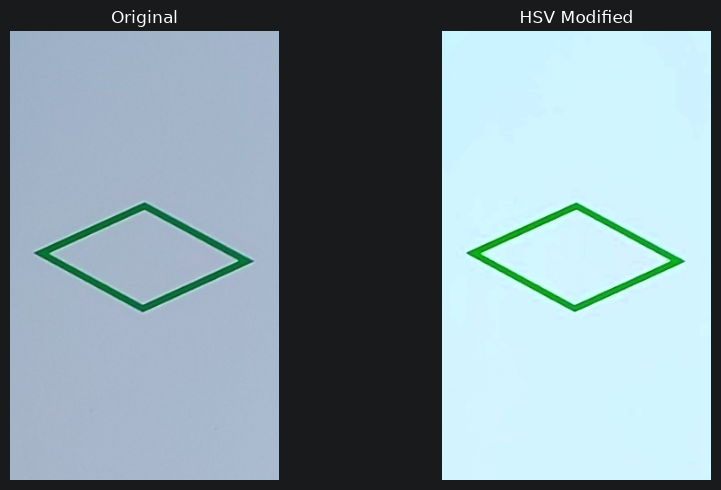

In [181]:
img = cv2.imread("cards - annotated/card0_g_1_l_v.jpg")
# Convert to HSV
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV).astype(np.float32)

# -----------------------
# Adjust these values
# -----------------------

hue_change = -10         # -180 ~ 180  10->blueish  20->purpleish  -10->green   (-10 to 10)
#sat_scale = 1          # 1 = no change
val_scale = 1.5          # 1 = no change  (0.8 to 1.5)

# -----------------------
# Apply changes
# -----------------------

# Hue (OpenCV uses range 0-179)
hsv[:, :, 0] = (hsv[:, :, 0] + hue_change) % 180

# Saturation
#hsv[:, :, 1] *= sat_scale

# Brightness (Value)
hsv[:, :, 2] *= val_scale

# Clip values
hsv[:, :, 1] = np.clip(hsv[:, :, 1], 0, 255)
hsv[:, :, 2] = np.clip(hsv[:, :, 2], 0, 255)

# Convert back to BGR
result = cv2.cvtColor(hsv.astype(np.uint8), cv2.COLOR_HSV2BGR)

# -----------------------
# Convert BGR -> RGB
# -----------------------
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

# -----------------------
# Display
# -----------------------
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(result_rgb)
plt.title("HSV Modified")
plt.axis("off")

plt.tight_layout()
plt.show()

### 2.2
Schreiben Sie eine Funktion, die für einen angegebenen Ordner sämtliche enthaltenen Bilder
mit dem Namen „card*.jpg“ einliest, die Annotation aus den Dateinamen ermittelt und zwei
Numpy-Arrays x_data und y_data zurückgibt, die im Folgenden als Daten (Eingabe- und
Ausgabewerte) für ein neuronales Netz dienen.

In [143]:
VALUE_UNKNOWN=-1

folder_path = "cards - annotated"

label_map = {
    "color": 0,
    "number": 1,
    "filling": 2,
    "form": 3
}

color_map = {
    "_r_": 0,
    "_g_": 1,
    "_b_": 2
}

number_map = {
    "_1_": 0,
    "_2_": 1,
    "_3_": 2
}

filling_map = {
    "_l_": 0,
    "_s_": 1,
    "_f_": 2
}


form_map = {
    "_o": 0,
    "_v": 1,
    "_t": 2
}


In [144]:
def get_single_label(filename, label_map):
    label=VALUE_UNKNOWN
    for key, val in label_map.items():
                if key in filename:
                    label = val
    return label

In [145]:
import os

def get_dataset():
    images = []
    labels = []
    filenames=[]

    for filename in os.listdir(folder_path):

        label=[VALUE_UNKNOWN]*4

        if filename.lower().endswith((".png", ".jpg", ".jpeg")):
            file_path = os.path.join(folder_path, filename)
        else :
            continue

        label[0]=get_single_label(filename, color_map)
        label[1]=get_single_label(filename, number_map)
        label[2]=get_single_label(filename, filling_map)
        label[3]=get_single_label(filename, form_map)

        #load image
        img=cv2.imread(file_path)
        img=cv2.resize(img, (96, 96))

        images.append(img)
        labels.append(label)
        filenames.append(filename)

    X = np.array(images)
    y = np.array(labels)
    filenames_np=np.array(filenames)

    print("X shape:", X.shape)
    print("y shape:", y.shape)

    return X,y, filenames_np


In [146]:
X_whole, y_whole, filenames=get_dataset()
print(y_whole)

X shape: (269, 96, 96, 3)
y shape: (269, 4)
[[1 0 0 1]
 [2 2 1 2]
 [0 2 1 0]
 ...
 [2 2 0 0]
 [2 0 2 2]
 [1 0 2 2]]


In [147]:
import os


def get_dataset(dataset_type):
    images = []
    labels = []

    for filename in os.listdir(folder_path):

        if filename.lower().endswith((".png", ".jpg", ".jpeg")):
            file_path = os.path.join(folder_path, filename)
        else :
            continue


        label = None  # track if we find a match

        if dataset_type == "color":
            # --- label logic ---
            for key, val in color_map.items():
                if key in filename:
                    label = val
                    break
        elif dataset_type == "number":
            for key, val in number_map.items():
                if key in filename:
                    label = val
                    break
        elif dataset_type == "filling":
            for key, val in filling_map.items():
                if key in filename:
                    label = val
                    break
        elif dataset_type == "form":
            for key, val in form_map.items():
                if key in filename:
                    label = val
                    break
        else:
            print("Please enter a valid dataset type")
            return None

        if label is None: continue

        # --- load image ---
        img = cv2.imread(file_path)
        img=cv2.resize(img, (96, 96))

        images.append(img)
        labels.append(label)

            # convert to numpy arrays
    X = np.array(images)
    y = np.array(labels)

    print("X shape:", X.shape)
    print("y shape:", y.shape)

    return X,y




### 2.3
Schreiben Sie eine Funktion, die die so ermittelten Daten zufällig in 90% Trainingsdaten
und 10% Testdaten aufteilt. Achten Sie darauf, dass Ein- und Ausgabedaten auf die gleiche
Weise aufgeteilt werden

In [148]:
"""
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.1,
    shuffle=True,
    random_state=42
)
"""

def train_test_split(X, y, filenames,test_size=0.1):
    n=len(X)

    #create shuffeled indices
    indices=np.random.permutation(n)

    #determine the split point
    split=int(n*(1-test_size))

    #get train, test indices
    train_indices=indices[:split]
    test_indices=indices[split:]

    #get train, test dataset
    train_X=X[train_indices]
    train_y=y[train_indices]
    train_filenames=filenames[train_indices]
    test_X=X[test_indices]
    test_y=y[test_indices]
    test_filenames=filenames[test_indices]

    return train_X, train_y, test_X, test_y, train_filenames, test_filenames


In [149]:
train_X, train_y, test_X, test_y,train_filenames, test_filenames=train_test_split(X_whole, y_whole, filenames)
print(test_y)

[[ 0  1  2  1]
 [ 1  1  2  2]
 [ 0  0  1  0]
 [ 1  0  0  0]
 [ 2  0  0  2]
 [ 1  2  0  0]
 [ 1  1  1  2]
 [ 1  2  2  0]
 [ 2  2  1  2]
 [ 0  0  0  2]
 [ 1  1  1  2]
 [ 0  1  0  2]
 [ 0  0  0  0]
 [ 1  0  0  1]
 [ 0  0  1  1]
 [ 1  0  1  0]
 [ 1  2  2  2]
 [ 2  2  1  2]
 [ 1 -1  1  1]
 [ 2  0  1  1]
 [ 1  1  0  0]
 [ 1  0  0  0]
 [ 0  0  1  2]
 [ 1  0  1  1]
 [ 2  1  0  1]
 [ 1  1  2  0]
 [ 1  1  1  1]]


In [150]:
print(train_y)

[[ 0  1  0  0]
 [ 1  0  0  0]
 [ 1  0  2  1]
 [ 1  0  0  1]
 [ 1  1  2  0]
 [ 0  0  1  2]
 [ 0  2  0  0]
 [ 2  2  1  0]
 [ 0  0  2  1]
 [ 2  1  2  0]
 [ 1  2  2  1]
 [ 2  2  2  2]
 [ 0  1  0  1]
 [ 1  0  0  2]
 [ 2  0  1  0]
 [ 2  1  1  0]
 [ 2  0  0  0]
 [ 1  0  0  1]
 [ 1  0  0  2]
 [ 1  2  2  0]
 [ 0  0  2  1]
 [ 1  0  0  2]
 [ 2  0  2  2]
 [ 1  1  0  1]
 [ 0  0  0  0]
 [ 0  1  2  0]
 [ 2  1  2  1]
 [ 1  2  1  2]
 [ 1  2  1  0]
 [ 2  1  2  0]
 [ 1  0  0  0]
 [ 2  0  2  0]
 [ 2  1  1  1]
 [ 1  1  0  2]
 [ 0  2  0  2]
 [ 2  2  2  1]
 [ 0  1  1  1]
 [ 0  0  2  0]
 [ 2  2  1  2]
 [ 0  1  1  0]
 [ 0  1  0  0]
 [ 0  0  1  0]
 [ 2  0  1  2]
 [ 2  2  2  1]
 [ 1  2  1  0]
 [ 0  1  1  0]
 [ 2  0  2  2]
 [ 0  2  2  1]
 [ 0  0  2  2]
 [ 1  2  0  2]
 [ 0  2  2  1]
 [ 2  0  0  1]
 [ 1  0  2  2]
 [ 1  1  2  1]
 [ 2  0  2  2]
 [ 2  2  0  1]
 [ 1  1  2  2]
 [ 0  2  0  2]
 [ 1  2  0  0]
 [ 0  2  2  1]
 [ 0  1  2  1]
 [ 0  1  0  1]
 [ 1  1  1  1]
 [ 0  1  2  2]
 [ 0  0  1  1]
 [ 1  0  2  2]
 [ 0  2  1

### 2.4
Erstellen Sie eine Funktion, um die Daten der Ausgabewerte (y_data bzw. y_train und
y_test) auf eine wählbare der vier Eigenschaften (Farbe, Anzahl, Füllung und Form)
einzuschränken.

In [151]:
def get_specific_labels(y, label_type):

    return y[:,label_map[label_type.lower()]]

[0 1 0 1 2 1 1 1 2 0 1 0 0 1 0 1 1 2 1 2 1 1 0 1 2 1 1]


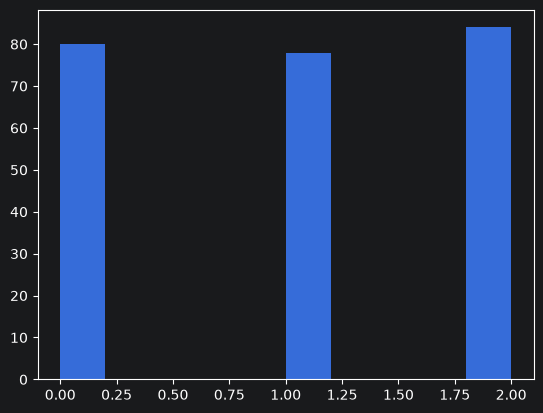

In [152]:
test_y_color=get_specific_labels(test_y,"color")
print(test_y_color)

train_y_color=get_specific_labels(train_y,"color")
plt.hist(train_y_color)
plt.show()

In [153]:
train_y_number=get_specific_labels(train_y,"number")
test_y_number=get_specific_labels(test_y,"number")


In [154]:

train_y_filling = get_specific_labels(train_y, "filling")
test_y_filling = get_specific_labels(test_y, "filling")

In [155]:
train_y_form = get_specific_labels(train_y, "form")
test_y_form = get_specific_labels(test_y, "form")

### 2.5
Implementieren Sie mit Keras unter Verwendung der vorangehenden Funktion ein
neuronales Netz für die Erkennung von wahlweise Farbe, Form, Anzahl und Füllung der
Karten. Wählen Sie hierzu eine geeignete Netzstruktur. Wie viele Epochen sind Ihrer
Meinung nach sinnvoll? Welche der vier Eigenschaften lässt sich auf diese Weise am besten
bzw. am schlechtesten erkennen?

In [156]:
from tensorflow.keras import layers, models
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping


def train_model(train_X, train_y, test_X, test_y, num_of_epoch):
    #remove the outliers:
    mask = train_y != VALUE_UNKNOWN

    train_X = train_X[mask]
    train_y = train_y[mask]

    mask=test_y!=VALUE_UNKNOWN

    test_X = test_X[mask]
    test_y = test_y[mask]

    train_X=tf.keras.utils.normalize(train_X, axis=1)  #convert all the values between 0 and 1-> easier for the system to calculate
    test_X=tf.keras.utils.normalize(test_X, axis=1)

    # Build CNN model
    model = models.Sequential([
        tf.keras.layers.Input(shape=(96, 96, 3)),

        # Convolution block 1
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        # Convolution block 2
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        # Flatten + Dense layers
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(3, activation='softmax')
    ])


    # early_stop = EarlyStopping(
    #     monitor='val_accuracy',   # or 'val_loss'
    #     patience=2,               # how many epochs to wait before stopping
    #     restore_best_weights=True # keeps best model automatically
    # )

    # Compile model
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    #model.summary()

    history = model.fit(
        train_X,
        train_y,
        epochs=num_of_epoch,
        validation_data=(test_X, test_y),  # this gives test/validation accuracy per epoch
        #callbacks=[early_stop]
    )

    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Test Accuracy')

    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('CNN Training vs Test Accuracy')
    plt.legend()
    plt.show()

    print(f"Final training accuracy: {history.history['accuracy'][-1]:.4f}")
    print(f"Final test accuracy: {history.history['val_accuracy'][-1]:.4f}")

In [157]:
x_train=tf.keras.utils.normalize(train_X, axis=1)
#print(x_train[0])
print(x_train.dtype)
print(train_y_color.dtype)
#print(type(y_train))
print(train_y_color[:10])

float64
int64
[0 1 1 1 1 0 0 2 0 2]


Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 102ms/step - accuracy: 0.3595 - loss: 1.1141 - val_accuracy: 0.2593 - val_loss: 1.0902
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.3760 - loss: 1.0877 - val_accuracy: 0.2963 - val_loss: 1.1003
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.5041 - loss: 1.0004 - val_accuracy: 0.2222 - val_loss: 1.0195
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.5909 - loss: 0.8120 - val_accuracy: 0.4444 - val_loss: 0.9764
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.7066 - loss: 0.6062 - val_accuracy: 0.8889 - val_loss: 0.5735
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.8471 - loss: 0.3681 - val_accuracy: 0.5556 - val_loss: 0.5259
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.8926 - loss: 0.2412 - val_accuracy: 0.9630 - val_loss: 0.2159
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.9298 - loss: 0.1559 - val_accuracy: 0.9630 - val_loss: 0.1023

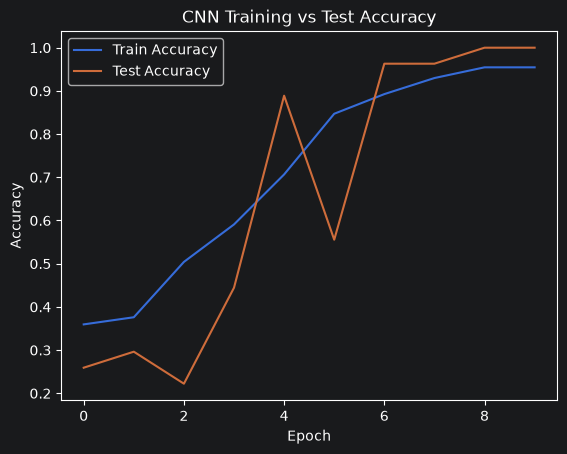

Final training accuracy: 0.9545
Final test accuracy: 1.0000


In [158]:
train_model(train_X, train_y_color, test_X, test_y_color, 10)

Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step - accuracy: 0.4149 - loss: 1.0810 - val_accuracy: 0.5000 - val_loss: 1.0086
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.9004 - loss: 0.6666 - val_accuracy: 1.0000 - val_loss: 0.1957
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 1.0000 - loss: 0.0387 - val_accuracy: 1.0000 - val_loss: 2.2964e-04
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 1.0000 - loss: 1.0896e-04 - val_accuracy: 1.0000 - val_loss: 3.9699e-05
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 1.0000 - loss: 7.8230e-05 - val_accuracy: 1.0000 - val_loss: 3.4846e-07
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 1.0000 - loss: 1.2740e-06 - val_accuracy: 1.0000 - val_loss: 1.8340e-08
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 1.0000 - loss: 8.0132e-08 - val_accuracy: 1.0000 - val_loss: 9.1699e-09
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 1.0000 - loss: 3.9077e-08 -

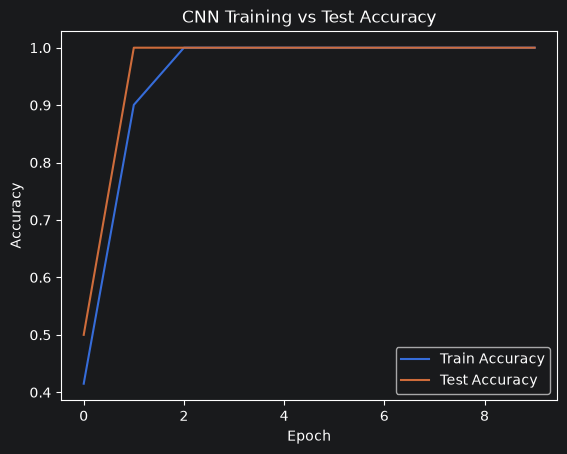

Final training accuracy: 1.0000
Final test accuracy: 1.0000


In [159]:
train_model(train_X, train_y_number, test_X, test_y_number, 10)

Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 105ms/step - accuracy: 0.3471 - loss: 1.0893 - val_accuracy: 0.1852 - val_loss: 1.0741
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.5041 - loss: 0.9215 - val_accuracy: 0.5556 - val_loss: 0.8836
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.6736 - loss: 0.6701 - val_accuracy: 0.5556 - val_loss: 0.7460
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.6529 - loss: 0.5062 - val_accuracy: 0.6296 - val_loss: 0.5724
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.6818 - loss: 0.4550 - val_accuracy: 0.5556 - val_loss: 0.5720
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.6653 - loss: 0.4468 - val_accuracy: 0.6296 - val_loss: 0.5597
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.6488 - loss: 0.4641 - val_accuracy: 0.6296 - val_loss: 0.5506
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 0.7066 - loss: 0.4376 - val_accuracy: 0.5926 - val_loss: 0.5598

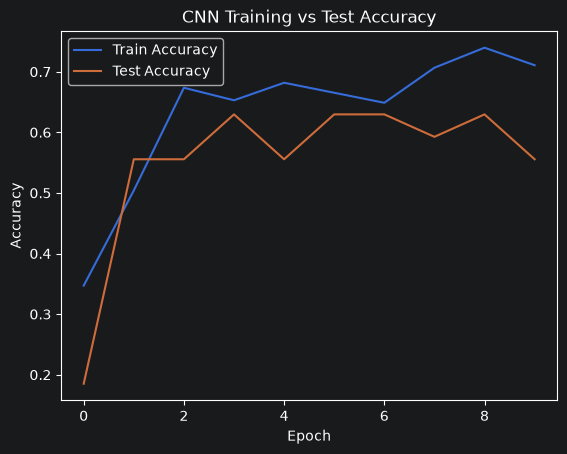

Final training accuracy: 0.7107
Final test accuracy: 0.5556


In [160]:
train_model(train_X, train_y_filling, test_X, test_y_filling, 10)

Epoch 1/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 101ms/step - accuracy: 0.3306 - loss: 1.1034 - val_accuracy: 0.3704 - val_loss: 1.0936
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 75ms/step - accuracy: 0.3430 - loss: 1.0973 - val_accuracy: 0.3704 - val_loss: 1.0903
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.5041 - loss: 1.0780 - val_accuracy: 0.3704 - val_loss: 1.0525
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.5909 - loss: 1.0071 - val_accuracy: 0.5926 - val_loss: 0.9415
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.7314 - loss: 0.7723 - val_accuracy: 0.7037 - val_loss: 0.6744
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 84ms/step - accuracy: 0.8471 - loss: 0.4440 - val_accuracy: 0.7407 - val_loss: 0.5183
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - accuracy: 0.9463 - loss: 0.1897 - val_accuracy: 0.9630 - val_loss: 0.3377
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - accuracy: 1.0000 - loss: 0.0491 - val_accuracy: 0.9630 - val_loss: 0.3838

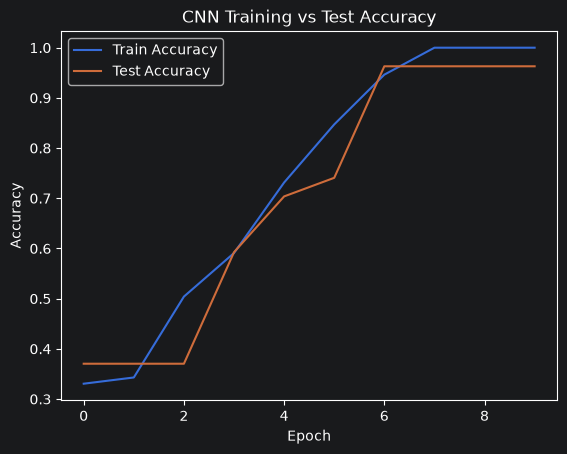

Final training accuracy: 1.0000
Final test accuracy: 0.9630


In [161]:
train_model(train_X, train_y_form, test_X, test_y_form, 10)

In [211]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def train_model2(train_X, train_y, test_X, test_y, num_of_epoch):
    seed = 42
    tf.keras.utils.set_random_seed(seed)

    #remove the outliers:
    mask = train_y != VALUE_UNKNOWN

    train_X = train_X[mask]
    train_y = train_y[mask]

    mask=test_y!=VALUE_UNKNOWN

    test_X = test_X[mask]
    test_y = test_y[mask]

    train_X=tf.keras.utils.normalize(train_X, axis=1)  #convert all the values between 0 and 1-> easier for the system to calculate
    test_X=tf.keras.utils.normalize(test_X, axis=1)

    # Build CNN model
    model = models.Sequential([
        tf.keras.layers.Input(shape=(96, 96, 3)),

        # Convolution block 1
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        # Convolution block 2
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        # # Flatten + Dense layers
        # layers.GlobalAveragePooling2D(),
        # layers.Dense(64, activation="relu"),
        # layers.Dense(32, activation='relu'),
        # layers.Dense(3, activation="softmax"),    #0.95

        # Flatten + Dense layers
        layers.Flatten(),
        # layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(16, activation='relu'),
        #layers.Dense(8, activation='relu'),
        layers.Dense(3, activation="softmax")
        #the accuracy is around 0.6 with 3 layers




    ])


    # early_stop = EarlyStopping(
    #     monitor='val_accuracy',   # or 'val_loss'
    #     patience=2,               # how many epochs to wait before stopping
    #     restore_best_weights=True # keeps best model automatically
    # )

    #optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)

    # Compile model
    model.compile(
        optimizer="adam",
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    #model.summary()

    history = model.fit(
        train_X,
        train_y,
        epochs=num_of_epoch,
        validation_data=(test_X, test_y),  # this gives test/validation accuracy per epoch
        #callbacks=[early_stop]
    )

    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Test Accuracy')

    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('CNN Training vs Test Accuracy')
    plt.legend()
    plt.show()

    print(f"Final training accuracy: {history.history['accuracy'][-1]:.4f}")
    print(f"Final test accuracy: {history.history['val_accuracy'][-1]:.4f}")

    y_pred = model.predict(test_X)
    y_pred_classes = np.argmax(y_pred, axis=1)
    cm = confusion_matrix(test_y, y_pred_classes)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix_test dataset")
    plt.show()

    y_pred = model.predict(train_X)
    y_pred_classes = np.argmax(y_pred, axis=1)
    cm = confusion_matrix(train_y, y_pred_classes)

    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix_train dataset")
    plt.show()

Epoch 1/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 96ms/step - accuracy: 0.3719 - loss: 1.0982 - val_accuracy: 0.1852 - val_loss: 1.0921
Epoch 2/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.3595 - loss: 1.0560 - val_accuracy: 0.6296 - val_loss: 0.9997
Epoch 3/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.6488 - loss: 0.8803 - val_accuracy: 0.6296 - val_loss: 0.8268
Epoch 4/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.6777 - loss: 0.6308 - val_accuracy: 0.7407 - val_loss: 0.6257
Epoch 5/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.7645 - loss: 0.4379 - val_accuracy: 0.6296 - val_loss: 0.5459
Epoch 6/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.7645 - loss: 0.4110 - val_accuracy: 0.6296 - val_loss: 0.5743
Epoch 7/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 71ms/step - accuracy: 0.7397 - loss: 0.4362 - val_accuracy: 0.8148 - val_loss: 0.4384
Epoch 8/30
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.7521 - loss: 0.4491 - val_accuracy: 0.8519 - val_loss: 0.4554


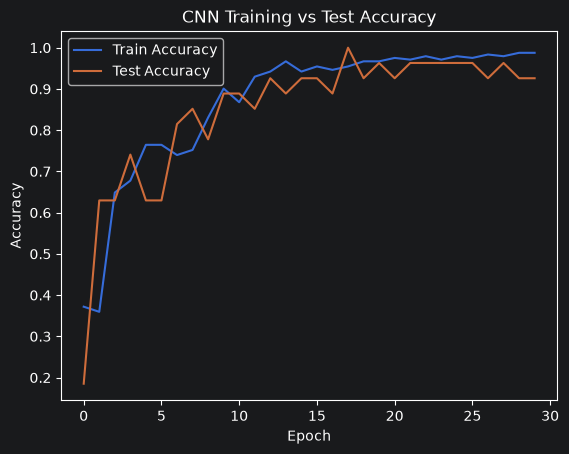

Final training accuracy: 0.9876
Final test accuracy: 0.9259
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step


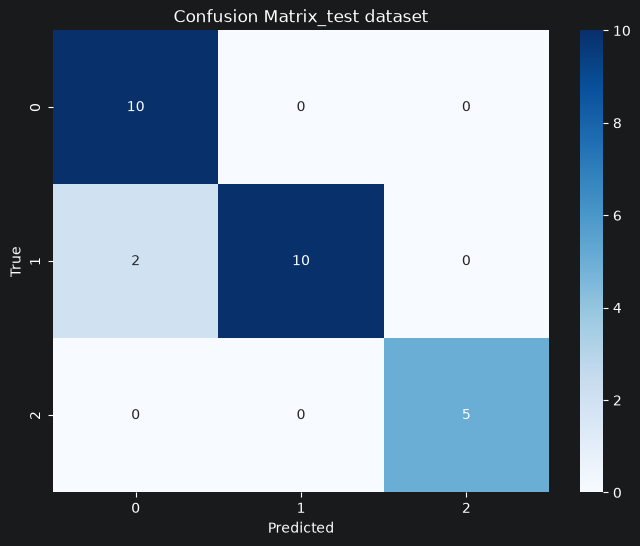

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step


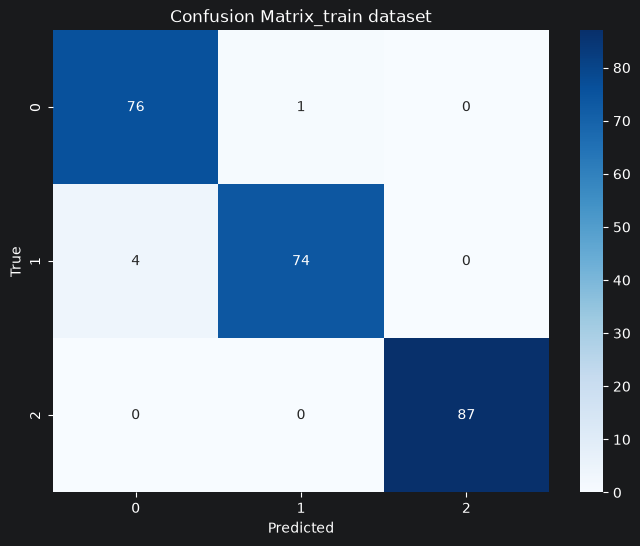

In [213]:
train_model2(train_X, train_y_filling, test_X, test_y_filling, 30)



[0 0 2 0 2 1 0 1 2 2 2 2 0 0 1 1 0 0 0 2 2 0 2 0 0 2 2 1 1 2 0 2 1 0 0 2 1
 2 1 1 0 1 1 2 1 1 2 2 2 0 2 0 2 2 2 0 2 0 0 2 2 0 1 2 1 2 1 2 1 0 2 0 1 2
 2 2 0 0 1 1 0 0 0 0 2 2 0 0 1 2 2 2 1 1 2 2 2 0 0 2 2 0 1 1 0 0 0 1 1 1 0
 1 2 2 1 2 0 2 1 0 2 2 1 2 1 0 2 2 0 0 1 0 1 1 2 2 0 1 0 2 1 0 0 0 2 1 1 2
 1 1 1 0 2 0 2 2 1 1 1 0 1 0 2 0 2 1 1 1 2 2 1 2 1 1 1 1 0 2 0 0 1 2 1 2 0
 1 2 1 0 1 0 2 2 2 0 0 0 0 2 1 0 0 1 2 2 1 1 1 1 1 0 0 2 1 0 2 2 1 1 0 0 2
 1 2 2 2 1 2 2 1 0 0 1 2 0 1 2 0 2 1 1 0]


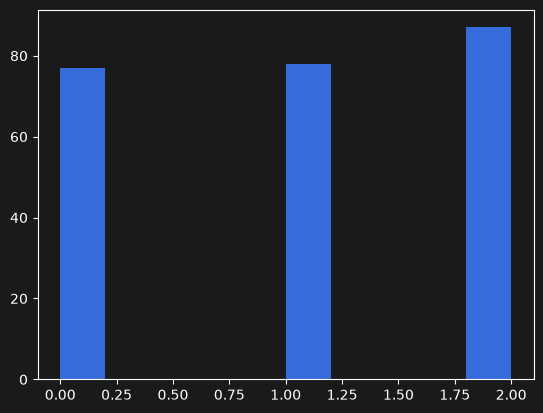

In [173]:
plt.hist(train_y_filling)
print(train_y_filling)